# **Proyecto de inteligencia artificial**

## Contexto

### Introduccion

Se descargaron 2 base de datos, uno indicando variables ambientales y otro de concentracion de quimicos, de corea del sur, los cuales se encuentran en el siguiente link:https://www.kaggle.com/datasets/calebreigada/south-korean-pollution

Ademàs existe una documentacion para la medicion de las variables ambientales:https://www.ncei.noaa.gov/data/global-hourly/doc/isd-format-document.pdf

Con el fin de entrenarlos en modelos de machine learning para predecir la concentracion de material particulado del tamaño de 2.5 micrometros en el ambiente.

### Objetivo:

Al tener 2 base de datos con informacion complementaria, nuestra meta es hacer un merge con tal de que se unan los datasets en uno solo, para esto tienen que ser iguales en fecha y ciudad.

El problema está en que no tienen mismo formato de fecha y su ubicacion geografica no es la misma. Esto se arreglara de la siguiente forma:



> Fecha: La fecha de uno de los data set indica la concentracion en el dia de cierto quimico, mientras que uno mide variables ambientales cada 1 o 3 horas, aproximadamente. Para lograr hacer el merge se tendra que pasar el formato del segundo data set, al del primer set, ya que, no tenemos los valores por hora del primero, pero si podemos sacar valores estadisticos (minimo, maximo y promedio) del segundo data set para un dia en vez de cada hora del dia. Asique se tendrá que crear otro dataset que contenga solo los dias y los valores aproximados del segundo dataset.



> Ciudad:  El primer dataset (quimicos) contiene informacion de una zona urbana (puede ser una villa, un pueblo, un distrito, etc...) donde se tomaron los datos, mientras que el segundo indica la ciudad donde se ubica la estacion que toman los datos, estas ciudades son las capitales de las provincias,segun los valores de longitud y latitud, no eiste ciudad donde se tomen ambos datos. Para solucionar esta se calculò las distancias minimas de cada estacion con las ciudades, para asociar dicho valor ambientales tomadas por las estaciones con los datos de concentraciones de las ciudades.

Despues de hacer el merge se tendrà que analisar si es que los datos tomados pueden pertenecer al mismo data set o separarlas por estacion.


Posteriormente con los datos ya organizados, se analisarán y se separaran en datos de entrenamiento, testeo y validacion, asi entrenar los modelos de machine learning (random forest y support vector machine).

### Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from seaborn import pairplot, heatmap

import datetime
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from sklearn import svm

from sklearn.svm import SVC



from sklearn.decomposition import PCA

In [ ]:
# Lib to create maps
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster

# To display stuff in notebook
from IPython.display import display, Markdown

In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()

#Mueve el archivo a la ubicación correcta y asigna permisos
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets list -s "South Korean Pollution"

ref                                                      title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
calebreigada/south-korean-pollution                      South Korean Pollution                       3906637  2022-03-03 13:23:11.863000           2515         42                1  
saurabhshahane/population-genetic-structure-of-eelgrass  Population genetic structure of eelgrass       60944  2021-04-18 16:01:01.830000             92          9       0.64705884  
jihyeseo/seoulairreport                                  Air pollutants measured in Seoul               44003  2017-11-24 14:43:19.923000           3146         40       0.88235295  


In [ ]:
!kaggle datasets download -d calebreigada/south-korean-pollution
!unzip south-korean-pollution.zip

Dataset URL: https://www.kaggle.com/datasets/calebreigada/south-korean-pollution
License(s): CC0-1.0
100% 3.73M/3.73M [00:00<00:00, 23.9MB/s]

Archive:  south-korean-pollution.zip
  inflating: south-korean-pollution-data.csv  
  inflating: south_korean_weather.csv  


#ETL

## Lectura de los data sets

In [ ]:
pollution=pd.read_csv("south-korean-pollution-data.csv")
pollution.head()

,Unnamed: 0,date,pm25,pm10,o3,no2,so2,co,Lat,Long,City,District,Country
0,0,2022/2/1,112,31,35,2,1,4,38.2089,127.9495,Bangsan-Myeon,Gangwon,South Korea
1,1,2022/2/2,92,21,35,2,1,0,38.2089,127.9495,Bangsan-Myeon,Gangwon,South Korea
2,2,2022/2/3,60,20,35,1,1,4,38.2089,127.9495,Bangsan-Myeon,Gangwon,South Korea
3,3,2022/2/4,51,27,33,1,1,4,38.2089,127.9495,Bangsan-Myeon,Gangwon,South Korea
4,4,2022/2/5,57,24,27,2,1,5,38.2089,127.9495,Bangsan-Myeon,Gangwon,South Korea


In [ ]:
Weather=pd.read_csv("south_korean_weather.csv")
Weather.head()

,Unnamed: 0,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,LIQUID_PRECIPITATION,SNOW_DEPTH,DEW,EXTREME_AIR_TEMP,ATMOSPHERIC_PRESSURE,SEA_LEVEL_PRESSURE,TEMP,VIS,WND
0,0,47112099999,"INCHEON, KS",37.466667,126.633333,70.0,2014-01-01T00:00:00,"12,0001,3,1",NaN,"+0005,1","120,N,+0024,1","99999,0,10054,1","10138,1","+0044,1","012000,1,9,9","270,1,N,0062,1"
1,1,47112099999,"INCHEON, KS",37.466667,126.633333,70.0,2014-01-01T06:00:00,NaN,NaN,"+0003,1",NaN,"99999,0,10046,1","10129,1","+0072,1","015000,1,9,9","270,1,N,0072,1"
2,2,47112099999,"INCHEON, KS",37.466667,126.633333,70.0,2014-01-01T09:00:00,NaN,NaN,"+0031,1",NaN,"99999,0,10051,1","10135,1","+0065,1","011000,1,9,9","270,1,N,0062,1"
3,3,47112099999,"INCHEON, KS",37.466667,126.633333,70.0,2014-01-01T12:00:00,"12,0000,2,1",NaN,"+0003,1","240,M,+0074,1","99999,0,10071,1","10155,1","+0058,1","008000,1,9,9","320,1,N,0051,1"
4,4,47112099999,"INCHEON, KS",37.466667,126.633333,70.0,2014-01-01T15:00:00,NaN,NaN,"-0031,1",NaN,"99999,0,10099,1","10184,1","+0030,1","013000,1,9,9","340,1,N,0051,1"


## Limpieza de datos

Verificacion de datos nulos.

In [ ]:
pd.concat([Weather.isnull().sum(),Weather.isnull().sum()/Weather.shape[0]*100],axis=1 ).rename(columns={0:"num nulos",1:"Porcentaje"})

,num nulos,Porcentaje
Unnamed: 0,0,0.000000
STATION,0,0.000000
NAME,0,0.000000
LATITUDE,0,0.000000
LONGITUDE,0,0.000000
ELEVATION,0,0.000000
DATE,0,0.000000
LIQUID_PRECIPITATION,129940,81.189158
SNOW_DEPTH,159686,99.775065
DEW,0,0.000000


Ya que, las columnas "LIQUID_PRECIPITATION", "SNOW_DEPTH" y "EXTREME_AIR_TEMP" tienen mas del 80% porciento datos faltantes, vamos a eliminarlos.

In [ ]:
Weather.columns

Index(['Unnamed: 0', 'STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'DATE', 'LIQUID_PRECIPITATION', 'SNOW_DEPTH', 'DEW', 'EXTREME_AIR_TEMP',
       'ATMOSPHERIC_PRESSURE', 'SEA_LEVEL_PRESSURE', 'TEMP', 'VIS', 'WND'],
      dtype='object')

Se omiten las columnas 'Unnamed: 0', para no repetir los indicces y la columna 'ATMOSPHERIC_PRESSURE' ya que ya existe la columa de presion, se decidio, atraves de una revision de los datos, tienen aproximadamente los mismos valores

In [ ]:
Weather = Weather[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'DATE',"ATMOSPHERIC_PRESSURE",  'SEA_LEVEL_PRESSURE','DEW', 'TEMP', 'VIS', 'WND']]


#### ATMOSPHERIC_PRESSURE V/S SEA_LEVEL_PRESSURE

In [ ]:
Weather.SEA_LEVEL_PRESSURE

,SEA_LEVEL_PRESSURE
0,"10138,1"
1,"10129,1"
2,"10135,1"
3,"10155,1"
4,"10184,1"
...,...
160041,"10232,1"
160042,"10231,1"
160043,"10230,1"
160044,"10231,1"




---
## Reorganizacion de datos.


In [ ]:
Weather_temp=Weather

Se observa que algunos valores son strings separados por comas.

In [ ]:
Weather_temp=Weather


In [ ]:
Weather_temp["DATE"]=pd.to_datetime(Weather_temp["DATE"], utc=False);

In [ ]:
pollution["date"]=pd.to_datetime(pollution["date"], utc=False);

In [ ]:
pollution["date"]

,date
0,2022-02-01
1,2022-02-02
2,2022-02-03
3,2022-02-04
4,2022-02-05
...,...
34525,2022-02-11
34526,2022-02-12
34527,2022-02-13
34528,2022-02-14


Tambien decir que en el caso del viento existian dos valores importantes, estos son el algulo con el que soplaba el viento con respecto al norte y la rapides.

La temperatura, el rocio, la presion a nivel del mar y la presion del aire esta en grados celsius con un factor de escala de 10, por lo que hay que dividir por ese factor

El siguiente codigo se logra hacer la limpieza:

In [ ]:
temp=Weather_temp["ATMOSPHERIC_PRESSURE"].str.split(",",expand=True).apply(pd.to_numeric)
Weather_temp=pd.concat([Weather_temp.drop("ATMOSPHERIC_PRESSURE",axis=1),temp],axis=1).rename(columns={0:"altimeter",1:"altimeter_code",2:"pressure",3:"pressure_code"})
Weather_temp["altimeter"]/=10
Weather_temp["pressure"]/=10


In [ ]:
temp=Weather_temp["WND"].str.split(",",expand=True)
Weather_temp=pd.concat([Weather_temp.drop("WND",axis=1),temp],axis=1)
Weather_temp=Weather_temp.rename(columns={0:"angle_nort",1:"angle_nort_code",2:"tipo de viento",3:"speed_rate",4:"speed_rate_code"})
Weather_temp["speed_rate"]=Weather_temp["speed_rate"].astype(float)/10

In [ ]:
temp=Weather_temp["DEW"].str.split(",",expand=True).apply(pd.to_numeric)
Weather_temp=pd.concat([Weather_temp.drop("DEW",axis=1),temp],axis=1).rename(columns={0:"DEW",1:"DEW_code"})
Weather_temp["DEW"]/=10

In [ ]:
temp=Weather_temp["TEMP"].str.split(",",expand=True).apply(pd.to_numeric)
Weather_temp=pd.concat([Weather_temp.drop("TEMP",axis=1),temp],axis=1).rename(columns={0:"TEMP",1:"TEMP_code"})
Weather_temp["TEMP"]/=10

In [ ]:
temp=Weather_temp["VIS"].str.split(",",expand=True).apply(pd.to_numeric)
Weather_temp=pd.concat([Weather_temp.drop("VIS",axis=1),temp],axis=1).rename(columns={0:"Distance",1:"Distance_code",2:"variability",3:"variability_code"})


In [ ]:
temp=Weather_temp["SEA_LEVEL_PRESSURE"].str.split(",",expand=True).apply(pd.to_numeric)
Weather_temp=pd.concat([Weather_temp.drop("SEA_LEVEL_PRESSURE",axis=1),temp],axis=1).rename(columns={0:"SEA_LEVEL_PRESSURE",1:"SEA_LEVEL_PRESSURE_code"})
Weather_temp["SEA_LEVEL_PRESSURE"]/=10

## Seleccion de ciudades

Se revisan las ciudades y las estaciones.

In [ ]:
pollution["City"].unique()

array(['Bangsan-Myeon', 'Cheongnim-Dong', 'Geumchon-Dong', 'Gwanak-Gu',
       'Hwasun-Eup', 'Hyeoksin-Dong', 'Jeongnim-Dong', 'Jungang-Way',
       'Juwol-Dong', 'Nowon-Gu', 'Onui-Dong', 'Pado-Ri', 'Paju',
       'Saemangeum', 'Saesol-Dong', 'Sangjusi', 'Seolseong-Myeon',
       'Seonggeoeup', 'Soi-Myeon', 'Taeha-Ri'], dtype=object)

A continuacion se plotearon segun su longitud y latitud, donde los puntos rojos son las posiciones de las estaciones (variables ambientales) y los puntos negros las ciudades (variables de concentracion de quimicos).


Y además, se sobrepuso a dos imagenes de corea del sur, una donde se aprecian algunas ciudades y la otra nos dice su elevacion, para tener una mejor visualizacion.

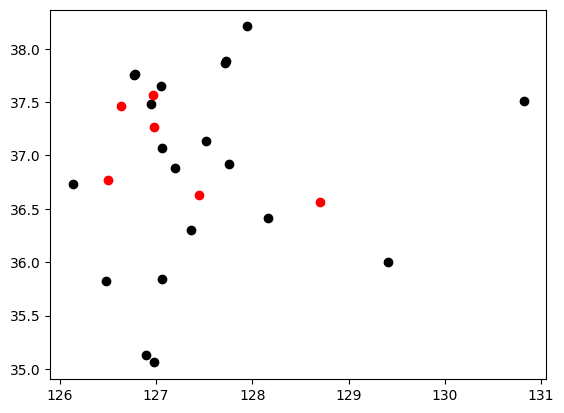

In [ ]:
plt.plot(pollution["Long"].unique(),pollution["Lat"].unique(),"ok")
plt.plot(Weather_temp["LONGITUDE"].unique(),Weather_temp["LATITUDE"].unique(),"or")

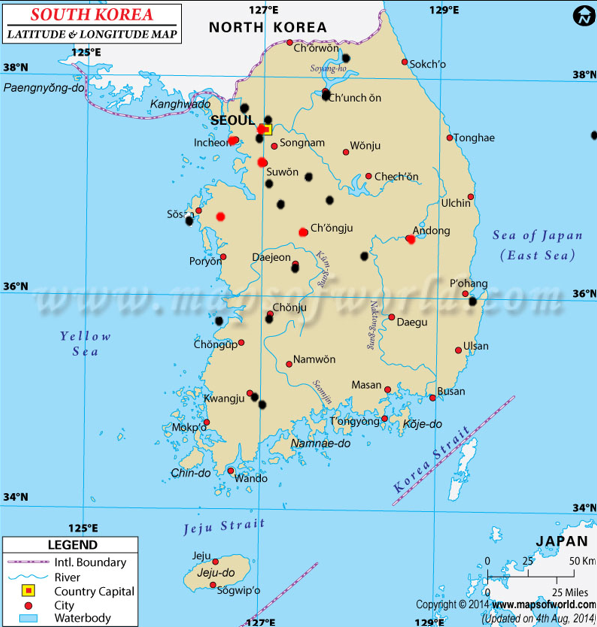

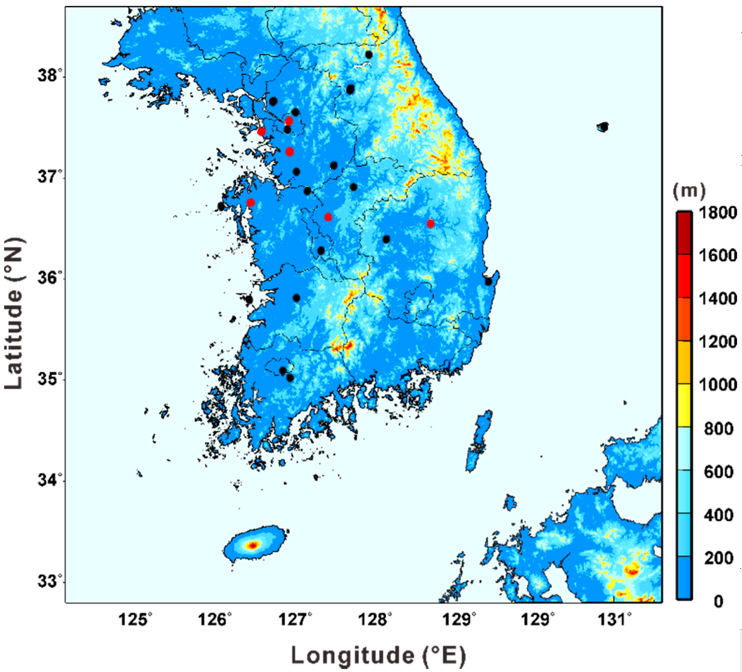

Con esta informacion, podemos descartar algunas ciudades, pero primero se ploteó un imshow, que muestra la distancia que tiene las ciudades en cada estacion, esto nos será ulti ala hora de elegir la ciudad "representante" de la estacion.

array([[ 3,  2, 12,  9, 14, 17, 16, 11, 10,  7, 18, 13,  6,  5,  0, 15,
         8,  4, 19,  1],
       [11, 17, 14, 13,  3,  2, 12,  6, 16, 18,  9,  5, 15,  8,  4, 10,
         7,  0,  1, 19],
       [ 3, 14,  9, 17, 16, 12,  2, 18, 10,  6,  7, 11,  5,  0, 13, 15,
         4,  8,  1, 19],
       [15,  1, 18,  6, 16, 17, 14, 10,  7,  5,  0,  3, 11,  9, 13, 19,
        12,  2,  4,  8],
       [ 6, 17, 16, 18, 14, 15,  5,  3, 11,  9, 10,  7, 13, 12,  2,  4,
         8,  0,  1, 19],
       [ 3,  9, 12,  2, 14, 17, 16, 10,  7, 18,  0, 11,  6,  5, 13, 15,
         8,  4, 19,  1]])

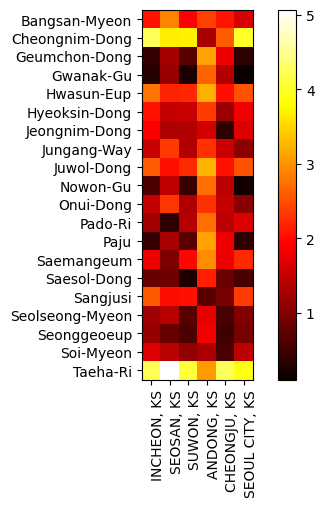

In [ ]:
X=np.stack((pollution["Lat"].unique(),pollution["Long"].unique()),axis=1)
Y=np.stack((Weather_temp["LATITUDE"].unique(),Weather_temp["LONGITUDE"].unique()),axis=1)
fig, ax = plt.subplots()
dist_sq = np.sum(np.abs((X[:, np.newaxis, :] - Y[np.newaxis, :, :])) , axis=-1)
im=ax.imshow(dist_sq,cmap="hot");
fig.colorbar(im);

ax.set_xticks(np.arange(len(Weather_temp["NAME"].unique())), labels=Weather_temp["NAME"].unique())
ax.set_yticks(np.arange(len(pollution["City"].unique())), labels=pollution["City"].unique())

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=90, ha="right",
         rotation_mode="anchor")

nearest = np.argsort(dist_sq.T, axis=1)
nearest_partition = np.argpartition(dist_sq.T, 2, axis=1)
nearest_partition

Se llegó a la conclusion de que las estaciones "ANDONG','INCHEON'y'SEOSAN", no proporcionaban datos utiles para nuestro estudio, las razones fueron:

> ANDONG: Estaba cerca de un lago, lo que puede provocar variaciones en la temperatura, por ejemplo y ademas no tenia una ciudad suficientemente cercana al cual asociar los datos





> INCHEON: La estacion, es una ciudad costera, por lo que no proporciona datos acordes con las ciudades cercanas


> SEOSAN: La ciudad mas cercana corresponde con ser una ciudad costera como lo es la estacion, pero no es una ciudad metropolitana como lo es SEOSAN, es mas bien una villa, lo que no es comparable con una ciudad con mas de un millon de habitantes.








Se seleccionaron las ciudades mas cercanas (en el caso de SUWON, se escogio la segunda, ya que la ciudad gwanak, estaba mucho mas cerca de SEOUL).

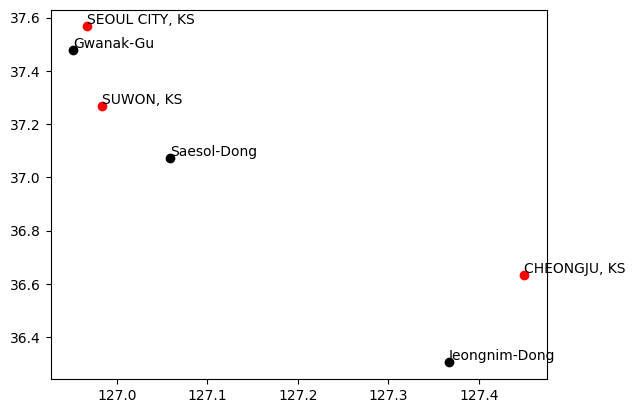

In [ ]:
delate_p=np.delete(pollution["City"].unique(),[nearest_partition[[2,4,5],[1,0,0]]])
delate_w=['ANDONG, KS','INCHEON, KS','SEOSAN, KS']
for i in delate_p:
  pollution.drop(pollution[(pollution["City"]==i )].index,inplace=True)
for i in delate_w:
  Weather_temp.drop(Weather_temp[(Weather_temp["NAME"]==i )].index,inplace=True)

plt.plot(pollution["Long"].unique(),pollution["Lat"].unique(),"ok")
plt.plot(Weather_temp["LONGITUDE"].unique(),Weather_temp["LATITUDE"].unique(),"or")
for i, label in enumerate(pollution["City"].unique()):
    plt.annotate(label, (pollution["Long"].unique()[i] , pollution["Lat"].unique()[i]+0.01))
for i, label in enumerate(Weather_temp["NAME"].unique()):
    plt.annotate(label, (Weather_temp["LONGITUDE"].unique()[i] , Weather_temp["LATITUDE"].unique()[i]+0.01))

In [ ]:
pollution["City"].unique()

array(['Gwanak-Gu', 'Jeongnim-Dong', 'Saesol-Dong'], dtype=object)

In [ ]:
Weather_temp["NAME"].unique()

array(['SUWON, KS', 'CHEONGJU, KS', 'SEOUL CITY, KS'], dtype=object)

## Sacando los missing (documento)

In [ ]:
Weather_temp.columns

Index(['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE',
       'altimeter', 'altimeter_code', 'pressure', 'pressure_code',
       'angle_nort', 'angle_nort_code', 'tipo de viento', 'speed_rate',
       'speed_rate_code', 'DEW', 'DEW_code', 'TEMP', 'TEMP_code', 'Distance',
       'Distance_code', 'variability', 'variability_code',
       'SEA_LEVEL_PRESSURE', 'SEA_LEVEL_PRESSURE_code'],
      dtype='object')

In [ ]:
principal_feature={'altimeter':9999.9,'pressure':9999.9,'angle_nort':999,'speed_rate':999.9,'DEW':999.9,'TEMP':999.9,'Distance':999999,'variability':999999,'SEA_LEVEL_PRESSURE':9999.9}

In [ ]:
principal_feature.keys()

dict_keys(['altimeter', 'pressure', 'angle_nort', 'speed_rate', 'DEW', 'TEMP', 'Distance', 'variability', 'SEA_LEVEL_PRESSURE'])

In [ ]:
print("Cantidad de valores missinsgs")
print("Total de filas: ",Weather_temp.shape[0])
for x in principal_feature.keys():
  print(x,": " ,Weather_temp[Weather_temp[x] == principal_feature[x]][x].shape[0])


Cantidad de valores missinsgs
Total de filas:  80063
altimeter :  80047
pressure :  3
angle_nort :  0
speed_rate :  17
DEW :  23
TEMP :  8
Distance :  243
variability :  0
SEA_LEVEL_PRESSURE :  19


La columna "altimeter" se eliminará, por que no aporta. las demas pueden ser cambiadas por el promedio o la media, pero al tratarse de pocos datos, se puede eliminar la fila.

In [ ]:
for x in principal_feature.keys():
  if x=="altimeter":
    pass
  else:
    Weather_temp.drop(Weather_temp[Weather_temp[x] == principal_feature[x]].index,inplace=True)
Weather_temp.drop(["altimeter","altimeter_code"],axis=1,inplace=True)

In [ ]:
Weather_temp.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,pressure,pressure_code,angle_nort,angle_nort_code,...,DEW,DEW_code,TEMP,TEMP_code,Distance,Distance_code,variability,variability_code,SEA_LEVEL_PRESSURE,SEA_LEVEL_PRESSURE_code
53292,47119099999,"SUWON, KS",37.266667,126.983333,35.0,2014-01-01 00:00:00,1010.9,1.0,050,1,...,-1.2,1,-0.1,1,6000,1,9,9,1015.2,1
53293,47119099999,"SUWON, KS",37.266667,126.983333,35.0,2014-01-01 06:00:00,1009.4,1.0,250,1,...,-6.0,1,8.6,1,15000,1,9,9,1013.5,1
53294,47119099999,"SUWON, KS",37.266667,126.983333,35.0,2014-01-01 09:00:00,1010.2,1.0,250,1,...,-0.2,1,6.3,1,12000,1,9,9,1014.4,1
53295,47119099999,"SUWON, KS",37.266667,126.983333,35.0,2014-01-01 12:00:00,1011.6,1.0,270,1,...,0.8,1,5.1,1,9000,1,9,9,1015.8,1
53296,47119099999,"SUWON, KS",37.266667,126.983333,35.0,2014-01-01 15:00:00,1014.1,1.0,320,1,...,-3.4,1,3.8,1,10000,1,9,9,1018.3,1



---
## Construccion de los datos finales.


Resumen:Se creó otro datasets, donde se alinean los valores de las estaciones y su ciudad correspondiente.

Se eligieron las siguientes columnas, cada varaible ambiental se le tomo su valor minimo, maximo y promedio, ya que, se tienen valores distinto a cada hora del dia, a excepcion de la presion, ya que, su valor no varia mucho se eligió el promedio del dia.

In [ ]:
pollution_update=pollution[['City','date', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co']]
pollution_update["Station"]=None

/tmp/ipykernel_1720/541111982.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pollution_update["Station"]=None


In [ ]:
asignacion={"Jeongnim-Dong":"CHEONGJU, KS","Gwanak-Gu":"SEOUL CITY, KS","Saesol-Dong":"SUWON, KS"}
pollution_update["Station"]=pollution_update[["Station","City"]].apply(lambda x: asignacion[x['City']] if pd.isna(x['Station']) else x['Station'],axis=1)

/tmp/ipykernel_1720/226139294.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pollution_update["Station"]=pollution_update[["Station","City"]].apply(lambda x: asignacion[x['City']] if pd.isna(x['Station']) else x['Station'],axis=1)


Ultima revision de datos


In [ ]:
Weather_temp=Weather_temp.convert_dtypes()
Weather_temp["speed_rate"]=Weather_temp["speed_rate"].astype(float)
Weather_temp["angle_nort"]=Weather_temp["angle_nort"].astype(float)

In [ ]:
Weather_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79775 entries, 53292 to 160045
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   STATION                  79775 non-null  Int64         
 1   NAME                     79775 non-null  string        
 2   LATITUDE                 79775 non-null  Float64       
 3   LONGITUDE                79775 non-null  Float64       
 4   ELEVATION                79775 non-null  Int64         
 5   DATE                     79775 non-null  datetime64[ns]
 6   pressure                 79774 non-null  Float64       
 7   pressure_code            79774 non-null  Int64         
 8   angle_nort               79775 non-null  float64       
 9   angle_nort_code          79775 non-null  string        
 10  tipo de viento           79775 non-null  string        
 11  speed_rate               79775 non-null  float64       
 12  speed_rate_code          79775 n

In [ ]:
pollution_update.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6366 entries, 6555 to 28167
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   City     6366 non-null   object        
 1   date     6366 non-null   datetime64[ns]
 2   pm25     6366 non-null   int64         
 3   pm10     6366 non-null   int64         
 4   o3       6366 non-null   int64         
 5   no2      6366 non-null   int64         
 6   so2      6366 non-null   int64         
 7   co       6366 non-null   int64         
 8   Station  6366 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 497.3+ KB


#SQL


## Base de datos SQLite:

In [ ]:
import sqlite3


Aqui defini una funcion para hacer la creacion de tablas, se que puedo crear la base datos con pd.to_sql, pero utilizaré llaves primarias y esta funcion no permite definirlas, por lo que, hay que hacerlas manualmente.

In [ ]:
def create_table_text(df, table_name, primary_key):
    tipo_pandas_to_sql = {
        "int64": "INTEGER",
        "float64": "REAL",
        "object": "TEXT",
        "bool": "BOOLEAN",
        "datetime64[ns]": "TIMESTAMP"
    }

    cols = []
    for col in df.columns:
        tipo = str(df[col].dtype)
        sql_type = tipo_pandas_to_sql.get(tipo, "TEXT")
        if col == primary_key:
            cols.append(f"{col} {sql_type} PRIMARY KEY")
        else:
            cols.append(f"{col} {sql_type}")

    col_defs = ",\n  ".join(cols)
    return f"""CREATE TABLE {table_name} (\n  {col_defs}\n);"""


In [ ]:
sql_code_pollution = create_table_text(pollution_update, "fact_pollution", primary_key="Station")
sql_code_wheater = create_table_text(Weather_temp, "dim_weather", primary_key="NAME")


In [ ]:
import sqlite3
import pandas as pd
database = sqlite3.connect('database.db')

In [ ]:

cursor = database.cursor()

# Crear tabla con clave primaria
cursor.execute(sql_code_pollution)
database.commit()

cursor.execute(sql_code_wheater)
database.commit()
# Luego cargas los datos

In [ ]:
pollution_update.to_sql("fact_pollution", database, if_exists="replace", index=False)
Weather_temp.to_sql("dim_weather", database, if_exists="replace", index=False)

79775

Con esto tenemos el dataset creado y listo para aplicar ciencia de datos.

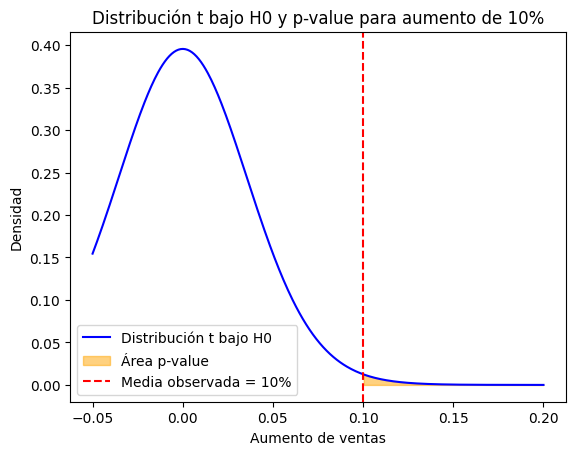

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

n = 30
df = n-1
mean_obs = 0.10  # 10%
s = 0.20
se = s / np.sqrt(n)

# rango de valores posibles de media bajo H0
x = np.linspace(-0.05, 0.20, 400)
y = t.pdf((x-0)/se, df)

plt.plot(x, y, color='blue', label='Distribución t bajo H0')
plt.fill_between(x, y, where=(x >= mean_obs), color='orange', alpha=0.5, label='Área p-value')
plt.axvline(mean_obs, color='red', linestyle='--', label='Media observada = 10%')
plt.xlabel('Aumento de ventas')
plt.ylabel('Densidad')
plt.title('Distribución t bajo H0 y p-value para aumento de 10%')
plt.legend()
plt.show()